In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

In [112]:
def find_equilibrium(supply, demand, flat_threshold=1e-10):
    """
    Find equilibrium quantity and price where demand >= supply.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        flat_threshold: tolerance for considering a curve "flat"
    
    Returns:
        q_eq: equilibrium quantity (number of trades)
        p_eq: equilibrium price
        p_supply: supply price at last trade
        p_demand: demand price at last trade
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    n = min(len(supply), len(demand))
    
    # Find last index where demand >= supply
    viable_mask = demand[:n] >= supply[:n]
    
    if not viable_mask.any():
        return 0, None, None, None
    
    last_idx = np.flatnonzero(viable_mask)[-1]
    next_idx = last_idx + 1
    
    q_eq = last_idx + 1
    p_supply = supply[last_idx]
    p_demand = demand[last_idx]
    
    # Check what happens at the next quantity unit
    has_next_supply = next_idx < len(supply)
    has_next_demand = next_idx < len(demand)
    
    # Determine price based on curve behavior at equilibrium
    if not has_next_supply:
        # Supply is vertical (ran out) - price based on demand side
        p_eq = (p_demand + demand[next_idx]) / 2 if has_next_demand else p_demand
    elif not has_next_demand:
        # Demand is vertical (ran out) - price based on supply side
        p_eq = (p_supply + supply[next_idx]) / 2 if has_next_supply else p_supply
    elif abs(supply[next_idx] - p_supply) < flat_threshold:
        # Supply is flat (perfectly elastic) - use supply price
        p_eq = p_supply
    elif abs(demand[next_idx] - p_demand) < flat_threshold:
        # Demand is flat (perfectly elastic) - use demand price
        p_eq = p_demand
    else:
        # Both curves have slope - use midpoint
        p_eq = (p_supply + p_demand) / 2
    
    return q_eq, p_eq, p_supply, p_demand

In [113]:
def plot_equilibrium(supply, demand, q_eq, p_eq, title=None, ax=None):
    """
    Visualize supply and demand curves with equilibrium point.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        q_eq: equilibrium quantity
        p_eq: equilibrium price
        title: optional plot title
        ax: optional matplotlib axes (creates new figure if None)
    
    Returns:
        matplotlib axes object
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    quantities_supply = np.arange(len(supply)) + 1
    quantities_demand = np.arange(len(demand)) + 1
    
    ax.step(quantities_supply, supply, 'b-', where='pre', label='Supply', linewidth=2)
    ax.step(quantities_demand, demand, 'r-', where='pre', label='Demand', linewidth=2)
    
    y_max = max(supply[-1], demand[0]) * 1.2
    
    # Extend supply vertically upward
    ax.vlines(len(supply), supply[-1], y_max, colors='blue', linewidth=2)
    
    # Extend demand vertically downward
    ax.vlines(len(demand), demand[-1], 0, colors='red', linewidth=2)
    
    if q_eq > 0 and p_eq is not None:
        ax.plot(q_eq, p_eq, 'go', markersize=12,
                label=f'Equilibrium: Q={q_eq}, P={p_eq:.2f}', zorder=5)
        ax.axhline(p_eq, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.axvline(q_eq, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(title or 'Supply and Demand - Equilibrium')
    ax.set_ylim(0, y_max)
    
    return ax


In [117]:
np.linspace(5, 1, 5)

array([5., 4., 3., 2., 1.])

TEST: 1. Normal intersection (both curves sloped)
Description: Classic X-shaped intersection. Price should be midpoint.



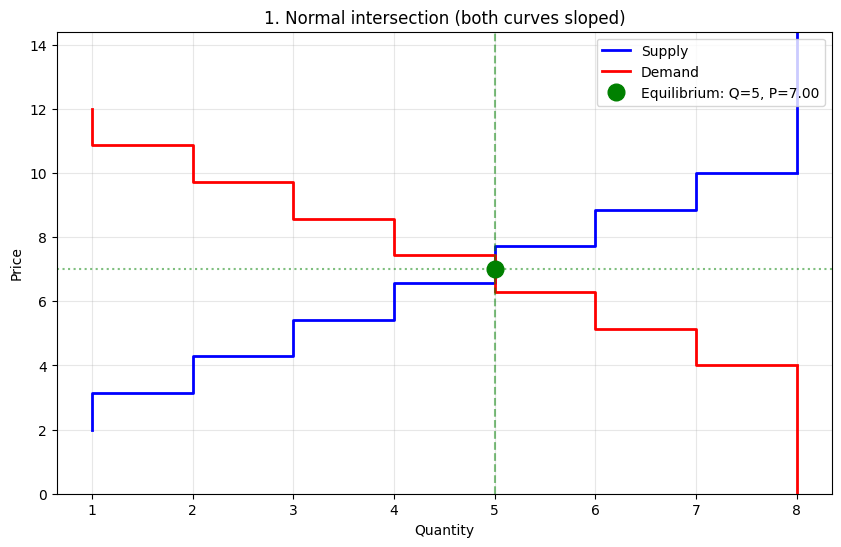

Results:
  Equilibrium quantity: 5
  Equilibrium price: 7.0
  Supply price at eq: 6.571428571428571
  Demand price at eq: 7.428571428571429

TEST: 2. Flat supply (perfectly elastic)
Description: Horizontal supply. Price should equal supply price.



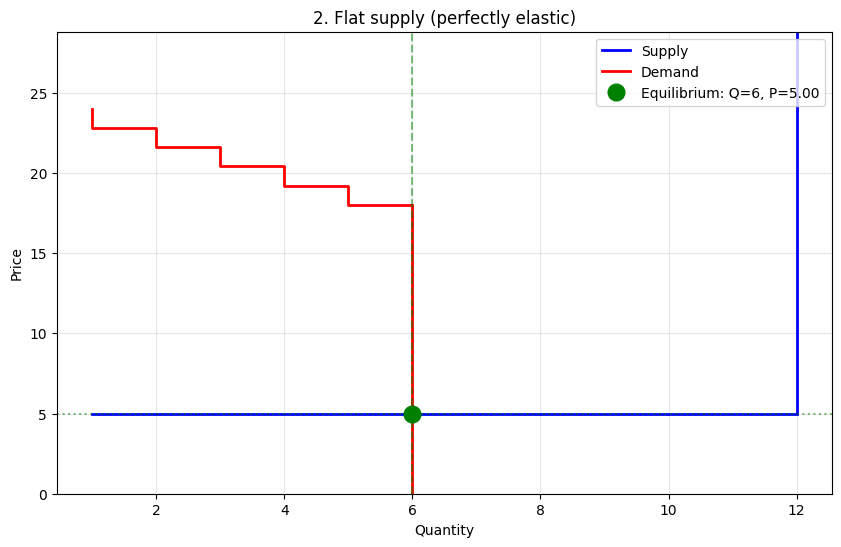

Results:
  Equilibrium quantity: 6
  Equilibrium price: 5.0
  Supply price at eq: 5
  Demand price at eq: 18.0

TEST: 3. Flat demand (perfectly elastic)
Description: Horizontal demand. Price should equal demand price.



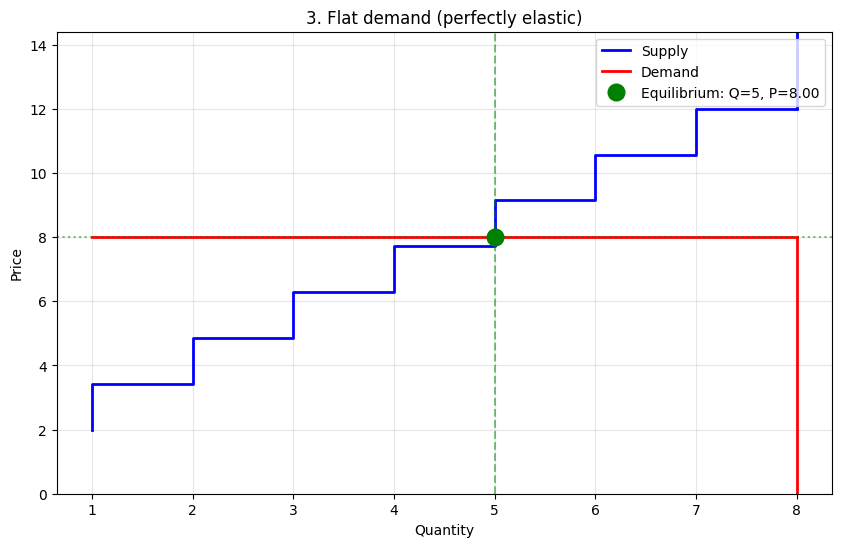

Results:
  Equilibrium quantity: 5
  Equilibrium price: 8
  Supply price at eq: 7.714285714285714
  Demand price at eq: 8

TEST: 4. Supply runs out first (vertical supply)
Description: Supply shorter than demand. Supply becomes vertical.



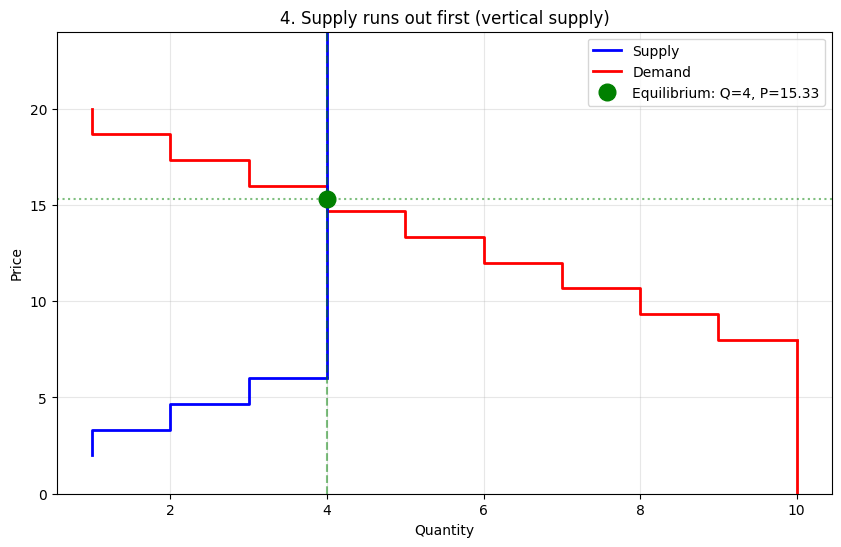

Results:
  Equilibrium quantity: 4
  Equilibrium price: 15.333333333333334
  Supply price at eq: 6.0
  Demand price at eq: 16.0

TEST: 5. Demand runs out first (vertical demand)
Description: Demand shorter than supply. Demand becomes vertical.



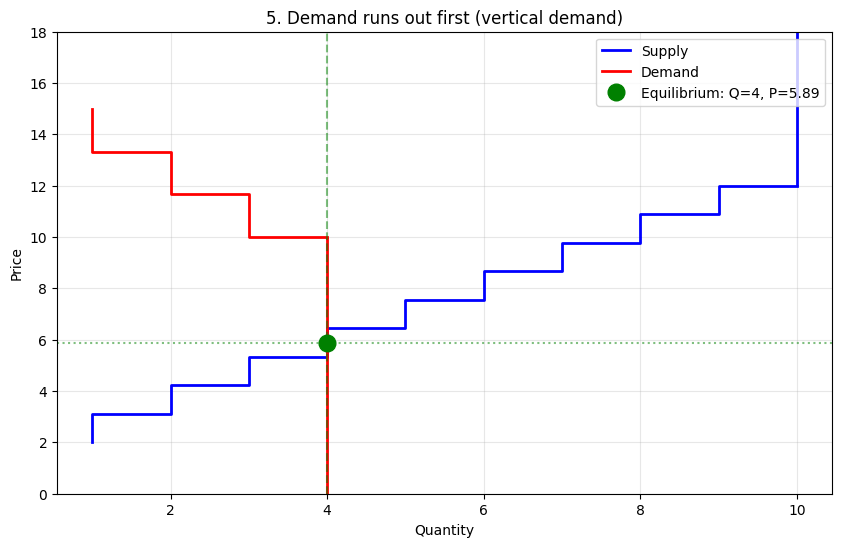

Results:
  Equilibrium quantity: 4
  Equilibrium price: 5.888888888888889
  Supply price at eq: 5.333333333333334
  Demand price at eq: 10.0

TEST: 6. No viable trades
Description: Supply always exceeds demand. No trades possible.



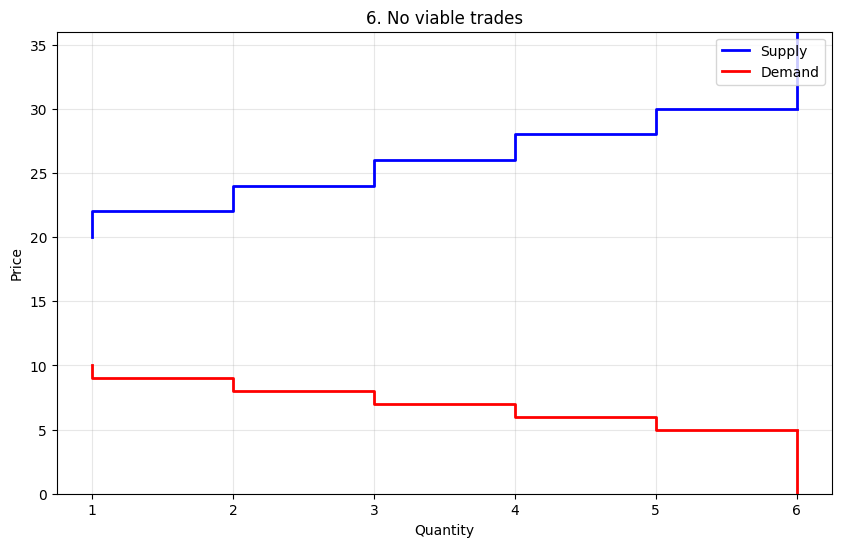

Results:
  Equilibrium quantity: 0
  Equilibrium price: None
  Supply price at eq: None
  Demand price at eq: None

TEST: 7. Single trade possible
Description: Only the first unit can trade.



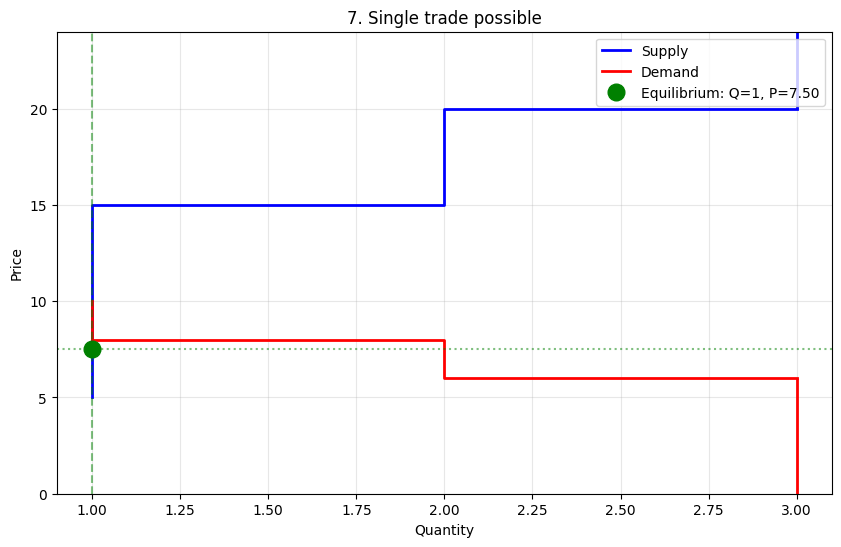

Results:
  Equilibrium quantity: 1
  Equilibrium price: 7.5
  Supply price at eq: 5
  Demand price at eq: 10

TEST: 8. Exact intersection (demand == supply)
Description: Curves cross exactly at one point.



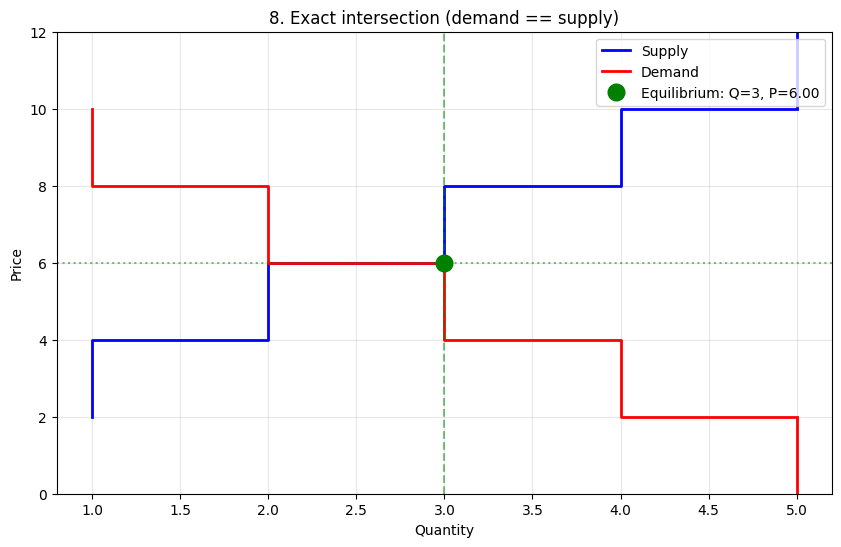

Results:
  Equilibrium quantity: 3
  Equilibrium price: 6.0
  Supply price at eq: 6
  Demand price at eq: 6



In [119]:
# =============================================================================
# TEST CASES
# =============================================================================

test_cases = [
    {
        "name": "1. Normal intersection (both curves sloped)",
        "supply": np.linspace(2, 10, 8),
        "demand": np.linspace(12, 4, 8),
        "description": "Classic X-shaped intersection. Price should be midpoint."
    },
    {
        "name": "2. Flat supply (perfectly elastic)",
        "supply": np.array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]),
        "demand": np.linspace(24, 18, 6),
        "description": "Horizontal supply. Price should equal supply price."
    },
    {
        "name": "3. Flat demand (perfectly elastic)",
        "supply": np.linspace(2, 12, 8),
        "demand": np.array([8, 8, 8, 8, 8, 8, 8, 8]),
        "description": "Horizontal demand. Price should equal demand price."
    },
    {
        "name": "4. Supply runs out first (vertical supply)",
        "supply": np.linspace(2, 6, 4),
        "demand": np.linspace(20, 8, 10),
        "description": "Supply shorter than demand. Supply becomes vertical."
    },
    {
        "name": "5. Demand runs out first (vertical demand)",
        "supply": np.linspace(2, 12, 10),
        "demand": np.linspace(15, 10, 4),
        "description": "Demand shorter than supply. Demand becomes vertical."
    },
    {
        "name": "6. No viable trades",
        "supply": np.linspace(20, 30, 6),
        "demand": np.linspace(10, 5, 6),
        "description": "Supply always exceeds demand. No trades possible."
    },
    {
        "name": "7. Single trade possible",
        "supply": np.array([5, 15, 20]),
        "demand": np.array([10, 8, 6]),
        "description": "Only the first unit can trade."
    },
    {
        "name": "8. Exact intersection (demand == supply)",
        "supply": np.array([2, 4, 6, 8, 10]),
        "demand": np.array([10, 8, 6, 4, 2]),
        "description": "Curves cross exactly at one point."
    },
]


"""Run all test cases with visualization."""
for tc in test_cases:
    print("=" * 60)
    print(f"TEST: {tc['name']}")
    print(f"Description: {tc['description']}")
    print()
    
    supply = tc['supply']
    demand = tc['demand']
    
    # Calculate equilibrium
    q_eq, p_eq, p_supply, p_demand = find_equilibrium(supply, demand)
    
    # Plot
    plot_equilibrium(supply, demand, q_eq, p_eq, title=tc['name'])
    plt.show()
    
    # Print results
    print(f"Results:")
    print(f"  Equilibrium quantity: {q_eq}")
    print(f"  Equilibrium price: {p_eq}")
    print(f"  Supply price at eq: {p_supply}")
    print(f"  Demand price at eq: {p_demand}")
    print()